# Transformer sequence reversal

Given a sequence of numbers as input, reverse the order of elements using an encoder-decoder transformer.

`[1 2 3 4 5] -> [5 4 3 2 1]`

Import dependencies.

In [44]:
import sys
sys.path.append('..')

import random
import autodiff.variable as variable
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

from autodiff.functions import softmax, dropout
from autodiff.variable import Variable, transpose
from nn.losses import cross_entropy
from nn.modules import Sequential, Embedding, Module, LayerNorm, Linear, ReLU, MultiHeadAttention
from nn.optimizers import SGD

Implement the encoder and decoder blocks.

`d_model` is the model input and output size of each token, `d_embed` is the size of the multi attention input and output and `n_heads` is the number of heads.

`d_model -> project -> d_embed -> split ->  d_embed/n_heads -> attention -> join -> d_embed -> project -> d_model` 

In [45]:
class EncoderBlock(Module):
    def __init__(self, d_ff: int, d_model: int, d_embed: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.ff = Sequential(Linear(d_model, d_ff),
                             ReLU(),
                             Linear(d_ff, d_model)
                             )
        self.layer_norm_1 = LayerNorm((d_model,))
        self.layer_norm_2 = LayerNorm((d_model,))
        self.multi_head_attention = MultiHeadAttention(d_model, d_embed, n_heads)
        self.dropout = dropout

    def forward(self, x: Variable, mask: Optional[np.ndarray] = None) -> Variable:
        y = self.multi_head_attention(x, x, x, mask)
        y = dropout(y, self.dropout, self.training)
        y = y + x
        y = self.layer_norm_1(y + x)

        y1 = self.ff(y)
        y1 = dropout(y1, self.dropout, self.training)
        return self.layer_norm_2(y1 + y)

In [46]:
class DecoderBlock(Module):
    def __init__(self, d_ff: int, d_model: int, d_embed: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.ff = Sequential(Linear(d_model, d_ff),
                             ReLU(),
                             Linear(d_ff, d_model)
                             )
        self.layer_norm_1 = LayerNorm((d_model,))
        self.layer_norm_2 = LayerNorm((d_model,))
        self.multi_head_attention_1 = MultiHeadAttention(d_model, d_embed, n_heads)
        self.multi_head_attention_2 = MultiHeadAttention(d_model, d_embed, n_heads)
        self.dropout = dropout

    def forward(self, encoder_out: Variable,
                x: Variable,
                in_mask: Optional[np.ndarray] = None,
                tgt_mask: Optional[np.ndarray] = None) -> Variable:
        y = self.multi_head_attention_1(x, x, x, tgt_mask)
        y = dropout(y, self.dropout, self.training)
        y = self.layer_norm_1(y + x)

        y1 = self.multi_head_attention_2(y, encoder_out, encoder_out, in_mask)
        y1 = dropout(y1, self.dropout, self.training)
        y1 = y1 + y

        y2 = self.ff(y1)
        y2 = dropout(y2, self.dropout, self.training)
        return self.layer_norm_2(y2 + y1)

Implement a function to apply positional encoding to the inputs.

$pos_{pos,i} = \begin{cases}
sin(pos/10000^{2i/n_{dims}}) \quad \text{if i is even}\\
cos(pos/10000^{2i/n_{dims}}) \quad \text{if i is odd}\\
\end{cases}$

In [47]:
def apply_positional_encoding(x: Variable):
    batch_size, seq_len, d_model = x.shape
    pos_enc = np.zeros_like(x)

    i = np.arange(0, d_model, dtype=np.int64)[None, ...]
    i = np.tile(i, (batch_size, seq_len, 1))

    pos = np.arange(0, seq_len)[..., None]
    pos_ext = np.tile(pos, (batch_size, 1, d_model))

    div = np.pow(10000, 2.0 * i / d_model)
    even_mask = i % 2 == 0
    pos_enc += np.sin(pos_ext / div) * even_mask

    odd_mask = i % 2 != 0
    pos_enc += np.cos(pos_ext / div) * odd_mask

    pos_enc = Variable(pos_enc)
    return pos_enc + x

Plot an example of positional encoding of sequence with 128 elements each of dimension 256.

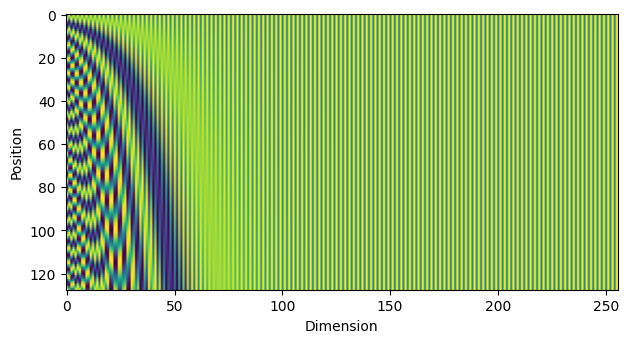

In [48]:
input = variable.random(1, 128, 256)
positional_encoding = apply_positional_encoding(input) - input

plt.imshow(positional_encoding[0].value)
plt.xlabel("Dimension")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

Implement the main transformer model.

In [49]:
class EncoderDecoderTransformer(Module):
    def __init__(self, d_ff: int,
                 d_model: int,
                 d_embed: int,
                 n_heads: int,
                 n_tokens: int,
                 pad_token: int,
                 n_encoders: int = 1,
                 n_decoders: int = 1):
        super().__init__()
        self.enc_embedding = Embedding(n_tokens, d_model)
        self.dec_embedding = Embedding(n_tokens, d_model)

        self.encoders = Sequential(
            *[EncoderBlock(d_ff, d_model, d_embed, n_heads, 0.01) for _ in range(n_encoders)])
        self.decoder = Sequential(
            *[DecoderBlock(d_ff, d_model, d_embed, n_heads, 0.01) for _ in range(n_decoders)])
        self.linear = Linear(d_model, n_tokens)

        self.d_model = d_model
        self.n_heads = n_heads
        self.pad_token = pad_token

    def get_causal_mask(self, x: Variable):
        mask = np.ones((x.shape[0], self.n_heads, x.shape[1], x.shape[1]))
        return ~(np.triu(mask, 1) == 0)

    def get_pad_mask(self, x_seq: Variable) -> np.ndarray:
        x_seq = x_seq.value
        m1 = np.expand_dims(x_seq == self.pad_token, 1)
        m1 = m1.repeat(x_seq.shape[-1], 1)
        m2 = m1.swapaxes(-2, -1)
        return np.expand_dims(m1 | m2, 1).repeat(self.n_heads, 1)

    def forward(self, x: Variable, y: Variable) -> Variable:
        tgt_mask = self.get_pad_mask(y)

        x, y = self.enc_embedding(x), self.dec_embedding(y)
        x, y = apply_positional_encoding(x), apply_positional_encoding(y)
        x, y = dropout(x, 0.01, self.training), dropout(y, 0.01, self.training)

        for enc in self.encoders:
            x = enc(x)
        causal_mask = self.get_causal_mask(y)
        for dec in self.decoder:
            y = dec(x, y, tgt_mask=causal_mask | tgt_mask)
        return self.linear(y)


Implement the Dataset. The extra tokens are chosen as follows:

|Pad|End of stream|Begin of stream|
|---|-------------|---------------|
|max + 1|max + 2|max + 3|

Where max is the maximum value of a sequence. Those are added to the generated sequence. Therefore the final sequence has length `seq_len +1`.

The length of the sequence is fixed but a random number of pad tokens is added to the encoder input. This is done because for simplicity the model accepts only fixed length sequences, so at inference time the decoder is presented with the currently generated tokens padded to the target length. For example for a dataset with maximium value of 50:

Input: `[1 2 3 4 5 52]`

Target: `[5 4 3 2 1 52]`

Decoder input: `[50 5 4 3 51 51]`

In this case the Decoder input has been padded with 2 tokens.

In [50]:
class NumberOrderingDataset:
    def __init__(self, n_sequences: int, n_max: int, seq_len: int):
        super().__init__()
        self.n_sequences = n_sequences
        self.n_max = n_max
        self.seq_len = seq_len
        self.start_token = n_max
        self.pad_token = n_max + 1
        self.eos_token = n_max + 2
        self.vocab_size = n_max + 3

    def __len__(self):
        return self.n_sequences

    def random_pad_seq(self, seq):
        n_pads = random.randint(0, self.seq_len // 2)
        if n_pads == 0:
            return seq
        pads = np.array([self.pad_token] * n_pads)
        return np.concat([seq[:-n_pads], pads])

    def __getitem__(self, item):
        seq_start = random.randint(0, self.n_max - self.seq_len)
        x = np.arange(seq_start, seq_start + self.seq_len).tolist()

        y = x[::-1]
        x_enc = x + [self.eos_token]

        # Randomly pad the decoder input, allowing the model to see partial sequences used in autoregressive prediction
        n_pad = random.randint(0, self.n_max // 2)
        x_dec = [self.start_token] + y[:n_pad] + [self.pad_token] * (len(y) - n_pad)

        y = y + [self.eos_token]
        return np.array(x_enc), np.array(y), np.array(x_dec)

Implement the dataloader. This allows to use batched input sequences.

In [51]:
class DataLoader:
    def __init__(self, data: NumberOrderingDataset, batch_size: int):
        super().__init__()
        self.batch_size = batch_size
        self.data = data
        self._iter_idx = 0
        self._idx = list(range(len(data)))
        random.shuffle(self._idx)

    def collate(self, samples: list):
        features = zip(*samples)
        batch = []
        for f in features:
            batch.append(Variable(np.stack(list(f))))
        return batch

    def __iter__(self):
        return self

    # Iterate over batches
    def __next__(self):
        if self._iter_idx >= len(self.data) - 1:
            self._iter_idx = 0
            random.shuffle(self._idx)
            raise StopIteration

        samples = []
        # Do not overshoot
        iter_size = min(self.batch_size, len(self.data) - self._iter_idx)
        for i in range(iter_size):
            samples.append(self.data[self._iter_idx + i])
        self._iter_idx += iter_size

        return self.collate(samples)

Implement helper functions to get the accuracy of the model and to extract sequences from output logits.

In [52]:
def get_sequence(pred: Variable) -> np.ndarray:
    proba = softmax(pred, dim=-1).value
    pred_c = np.argmax(proba, axis=-1, keepdims=True)
    return pred_c.squeeze()


def get_accuracy(pred: Variable, tgt: Variable):
    acc = np.abs(tgt.value - get_sequence(pred))
    acc[acc != 0] = 1
    return np.mean(1 - acc)

Implement a function to train the model and plot the results.

In [53]:
def plot_training(losses, accuracies):
    # Plot losses and accuracy
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2)

    steps = np.arange(len(losses))
    ax_loss.set_title('Loss')
    ax_loss.plot(steps, losses, c='orange')
    ax_loss.set_xlabel('Step')
    ax_loss.set_ylabel('Loss')

    ax_acc.set_title('Accuracy')
    ax_acc.plot(steps, accuracies)
    ax_acc.set_xlabel('Step')
    ax_acc.set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()


def train(model: EncoderDecoderTransformer, data_loader, epochs: int):
    model.set_training(True)
    optimizer = SGD(model.parameters(), lr=0.05)

    # Train
    losses = []
    accuracies = []
    for e in range(epochs):
        epoch_loss = []
        epoch_acc = []
        for (x, tgt, dec_x) in data_loader:
            pred = model(x, dec_x)

            # Transpose to have classes on dim -2
            pred = transpose(pred, -1, -2)
            loss = cross_entropy(pred, tgt)
            epoch_loss.append(loss.value)

            # Backpropagation and weights update
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Get accuracy
            pred = transpose(pred, -1, -2)
            acc = get_accuracy(pred, tgt)
            epoch_acc.append(acc * 100)

        epoch_loss = np.mean(epoch_loss)
        epoch_acc = np.mean(epoch_acc)
        # if epoch_acc == 100:
        #     break
        print(f'Epoch {e}: {epoch_loss} Accuracy: {epoch_acc}')
        losses.append(epoch_loss)
        accuracies.append(epoch_acc)

    plot_training(losses, accuracies)

Create the model, data and dataloader and begin training. Set the seed for reproducibility.

Epoch 0: 3.7229068550220044 Accuracy: 17.317708333333332
Epoch 1: 3.2954372322966874 Accuracy: 24.12109375
Epoch 2: 2.923144162291261 Accuracy: 46.41927083333333
Epoch 3: 2.60106434651959 Accuracy: 65.0390625
Epoch 4: 2.2741319942225116 Accuracy: 74.86979166666666
Epoch 5: 1.956672018010707 Accuracy: 75.78125
Epoch 6: 1.6155511047265037 Accuracy: 79.26432291666666
Epoch 7: 1.3253295344662481 Accuracy: 81.36393229166667
Epoch 8: 1.1138087384165218 Accuracy: 83.75651041666666
Epoch 9: 0.9358390258414812 Accuracy: 86.81640625
Epoch 10: 0.802953573960091 Accuracy: 88.70442708333333
Epoch 11: 0.6826966988518214 Accuracy: 90.673828125
Epoch 12: 0.6145826976534148 Accuracy: 91.357421875
Epoch 13: 0.509136375424327 Accuracy: 92.93619791666666
Epoch 14: 0.447246559613509 Accuracy: 93.53841145833333
Epoch 15: 0.4182624084334766 Accuracy: 93.52213541666667
Epoch 16: 0.3683248049027887 Accuracy: 94.20572916666666
Epoch 17: 0.3166188821087144 Accuracy: 94.98697916666666
Epoch 18: 0.3172007568896399

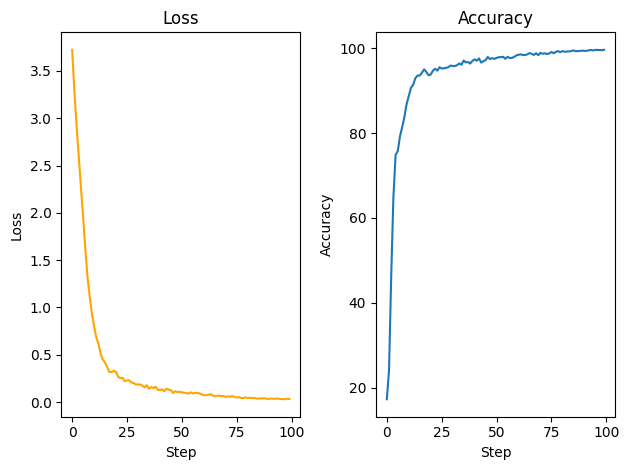

In [54]:
random.seed(8421)
n_max = 50
seq_len = 5
train_data = NumberOrderingDataset(1000, n_max, seq_len)
train_loader = DataLoader(train_data, batch_size=32)

transformer = EncoderDecoderTransformer(d_ff=128,
                                        d_model=32,
                                        d_embed=32,
                                        n_heads=2,
                                        n_tokens=train_data.vocab_size, pad_token=train_data.pad_token,
                                        n_encoders=1,
                                        n_decoders=1)

train(transformer, train_loader, 100)

Implement the inference function. The output is generated autoregressively by feeding the model the previously generated sequence. As this model accepts only fixed lenght sequences, the decoder input is padded with `pad_token`. For example given the following input:

Input: `[1 2 3 4 5 52]`

The decoder input is created as:

Decoder input: `[50 51 51 51 51 51]`

Then at each step the decoder input becomes:

- `[50 5 51 51 51 51]`
- `[50 5 4  51 51 51]`
- `[50 5 4  3  51 51]`
- `[50 5 4  3  2  51]`
- `[50 5 4  3  2  1 ]`

In [55]:
def inference(model, dataset):
    model.set_training(False)
    for _ in range(10):
        x, true, _ = dataset[random.randint(0, len(dataset))]
        x = Variable(np.expand_dims(x, 0))
        # Empty decoder input
        dec_x = np.array([[train_data.start_token] + [dataset.pad_token] * dataset.seq_len])

        for i in range(seq_len):
            y = model(x, Variable(dec_x))
            # Skip the start token
            dec_x[..., i + 1] = get_sequence(y)[..., i]

        # Remove extra tokens
        print(f'Input: {x.value.squeeze().tolist()[:-1]}')
        print(f'Predicted: {dec_x.squeeze().tolist()[1:]}\n')


Test the model on 10 random sequences.

In [56]:
inference(transformer, train_data)

Input: [26, 27, 28, 29, 30]
Predicted: [30, 29, 28, 27, 26]

Input: [40, 41, 42, 43, 44]
Predicted: [44, 43, 42, 41, 40]

Input: [12, 13, 14, 15, 16]
Predicted: [16, 15, 14, 13, 12]

Input: [26, 27, 28, 29, 30]
Predicted: [30, 29, 28, 27, 26]

Input: [24, 25, 26, 27, 28]
Predicted: [28, 27, 26, 25, 24]

Input: [13, 14, 15, 16, 17]
Predicted: [17, 16, 15, 14, 13]

Input: [8, 9, 10, 11, 12]
Predicted: [12, 11, 10, 9, 8]

Input: [10, 11, 12, 13, 14]
Predicted: [14, 13, 12, 11, 10]

Input: [0, 1, 2, 3, 4]
Predicted: [4, 3, 2, 1, 0]

Input: [8, 9, 10, 11, 12]
Predicted: [12, 11, 10, 9, 8]

